IMPORT LIBRARIES

DATA LOADING

DATA CLEANING

EDA

RFM ANALYSIS

CUSTOMER SEGMENTATION

RECOMMENDATION SYSTEM

SAVE MODELS

# Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity
import joblib
import warnings
warnings.filterwarnings("ignore")

#Data Loading

In [2]:
df = pd.read_csv("online_retail.csv")

In [3]:
df.info()
df.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 223156 entries, 0 to 223155
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    223156 non-null  object 
 1   StockCode    223156 non-null  object 
 2   Description  222290 non-null  object 
 3   Quantity     223155 non-null  float64
 4   InvoiceDate  223155 non-null  object 
 5   UnitPrice    223155 non-null  float64
 6   CustomerID   159541 non-null  float64
 7   Country      223155 non-null  object 
dtypes: float64(3), object(5)
memory usage: 13.6+ MB


np.int64(1859)

In [4]:
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,866
Quantity,1
InvoiceDate,1
UnitPrice,1
CustomerID,63615
Country,1


In [5]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,223155.000000,223155.000000,159541.000000
mean,9.347646,5.146552,15270.814781
std,228.422034,123.220287,1725.002263
min,-74215.000000,0.000000,12346.000000
25%,1.000000,1.250000,13831.000000
50%,3.000000,2.100000,15132.000000
75%,10.000000,4.210000,16809.000000
max,74215.000000,38970.000000,18287.000000


In [6]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6.0,2022-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6.0,2022-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8.0,2022-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6.0,2022-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6.0,2022-12-01 08:26:00,3.39,17850.0,United Kingdom


In [7]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 223156 entries, 0 to 223155
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    223156 non-null  object        
 1   StockCode    223156 non-null  object        
 2   Description  222290 non-null  object        
 3   Quantity     223155 non-null  float64       
 4   InvoiceDate  223155 non-null  datetime64[ns]
 5   UnitPrice    223155 non-null  float64       
 6   CustomerID   159541 non-null  float64       
 7   Country      223155 non-null  object        
dtypes: datetime64[ns](1), float64(3), object(4)
memory usage: 13.6+ MB


#Data Cleaning

In [8]:
df = df.drop_duplicates()
df.duplicated().sum()

np.int64(0)

In [9]:
df = df.dropna(subset=['CustomerID'])
df = df.dropna(subset=['Description'])
df = df.dropna(subset=['Country'])

In [10]:
df[df['InvoiceNo'].str.startswith('C')]
df = df[
    ~df['InvoiceNo'].str.startswith('C')
]

In [11]:
df = df[df['Quantity'] > 0]
df = df[df['UnitPrice'] > 0]

In [12]:
df['TotalAmount'] = (
    df['Quantity'] *
    df['UnitPrice']
)

In [13]:
df.shape

(153879, 9)

In [14]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID,TotalAmount
count,153879.000000,153879,153879.000000,153879.000000,153879.000000
mean,13.424210,2023-03-09 14:25:55.261731584,3.317973,15272.780808,23.355057
min,1.000000,2022-12-01 08:26:00,0.001000,12346.000000,0.001000
25%,2.000000,2023-01-20 15:22:00,1.250000,13838.000000,5.040000
50%,6.000000,2023-03-14 13:04:00,1.950000,15139.000000,12.750000
75%,12.000000,2023-04-28 15:13:00,3.750000,16812.000000,19.800000
max,74215.000000,2023-06-12 12:01:00,8142.750000,18287.000000,77183.600000
std,194.922617,NaN,25.253137,1725.823317,233.408307


In [15]:
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,0
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,0
Country,0
TotalAmount,0


# EDA

**Transaction Volume by Country**

The majority of transactions originate from the United Kingdom, indicating that the business primarily serves customers in this region. Other countries contribute a smaller share of transactions.



In [16]:
country_sales = (
    df.groupby('Country')['InvoiceNo']
    .count()
    .sort_values(ascending=False)
)

country_sales.head(10)

,InvoiceNo
Country,
United Kingdom,137049
Germany,3694
France,3245
EIRE,2383
Spain,1039
Netherlands,989
Belgium,816
Switzerland,678
Portugal,585


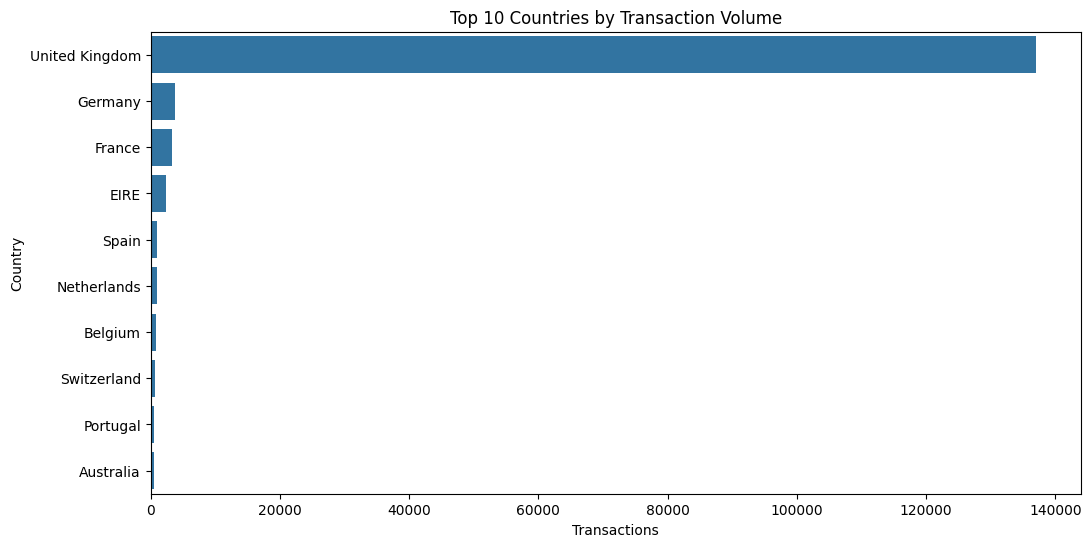

In [17]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=country_sales.head(10).values,
    y=country_sales.head(10).index
)

plt.title("Top 10 Countries by Transaction Volume")
plt.xlabel("Transactions")
plt.ylabel("Country")

plt.show()

**Top Selling Products**

The visualization highlights the products with the highest sales volume. These products can be prioritized for inventory planning and promotional campaigns.

In [18]:
top_products = (
    df.groupby('Description')['Quantity']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products

,Quantity
Description,
MEDIUM CERAMIC TOP STORAGE JAR,75205.0
WORLD WAR 2 GLIDERS ASSTD DESIGNS,29812.0
WHITE HANGING HEART T-LIGHT HOLDER,21198.0
JUMBO BAG RED RETROSPOT,19297.0
PACK OF 72 RETROSPOT CAKE CASES,19267.0
SMALL POPCORN HOLDER,17725.0
ASSORTED COLOUR BIRD ORNAMENT,14031.0
ASSORTED COLOURS SILK FAN,13584.0
PACK OF 60 PINK PAISLEY CAKE CASES,13202.0


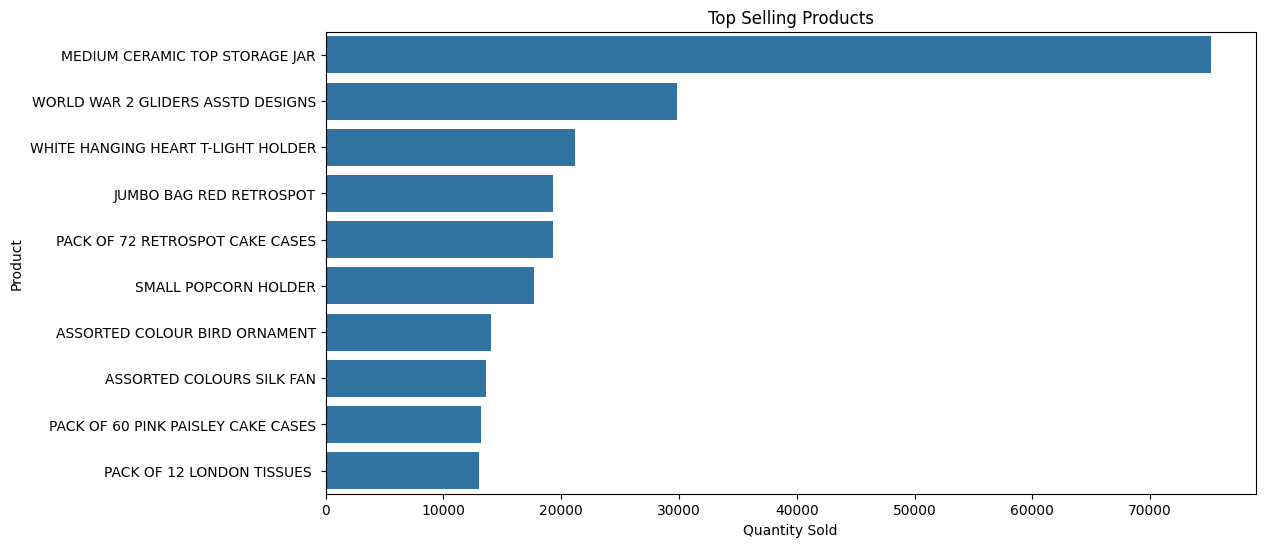

In [19]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=top_products.values,
    y=top_products.index
)

plt.title("Top Selling Products")
plt.xlabel("Quantity Sold")
plt.ylabel("Product")

plt.show()

**Monthly Sales Trend**

Monthly sales trends help identify seasonal purchasing patterns and periods of high customer activity.

In [20]:
df['Month'] = df['InvoiceDate'].dt.to_period('M')

In [21]:
monthly_sales = (
    df.groupby('Month')['TotalAmount']
    .sum()
)

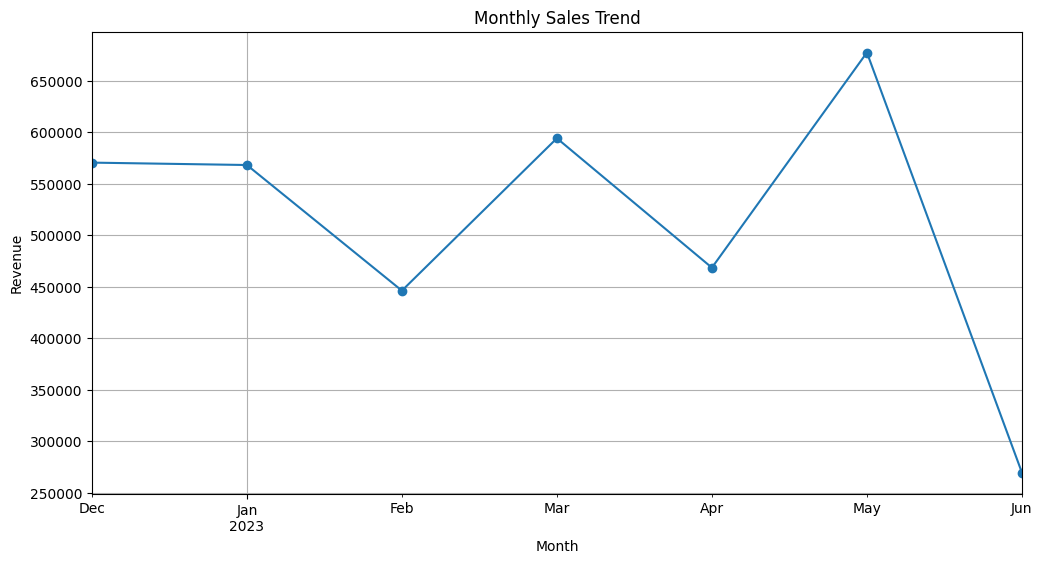

In [22]:
plt.figure(figsize=(12,6))

monthly_sales.plot(marker='o')

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.grid(True)

plt.show()

**Monetary Distribution**

Most transactions involve relatively low purchase amounts, while a few high-value transactions create a right-skewed distribution.

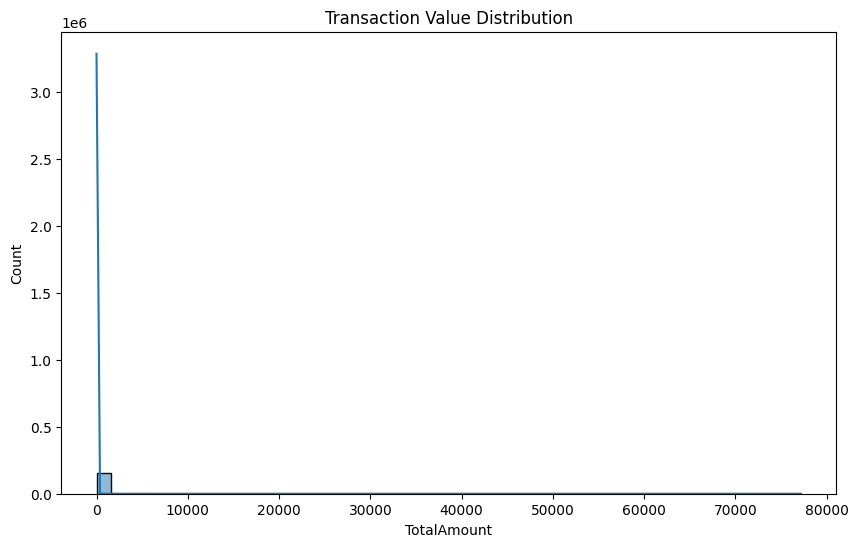

In [23]:
plt.figure(figsize=(10,6))

sns.histplot(
    df['TotalAmount'],
    bins=50,
    kde=True
)

plt.title("Transaction Value Distribution")

plt.show()

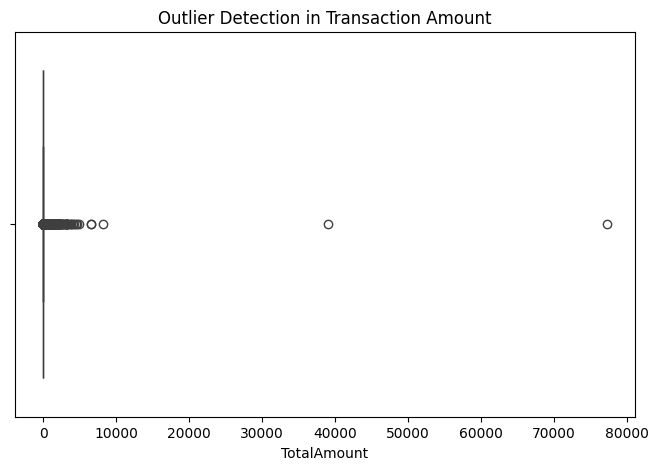

In [24]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x=df['TotalAmount']
)

plt.title("Outlier Detection in Transaction Amount")

plt.show()

**Top Customers**

In [25]:
top_customers = (
    df.groupby('CustomerID')['TotalAmount']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

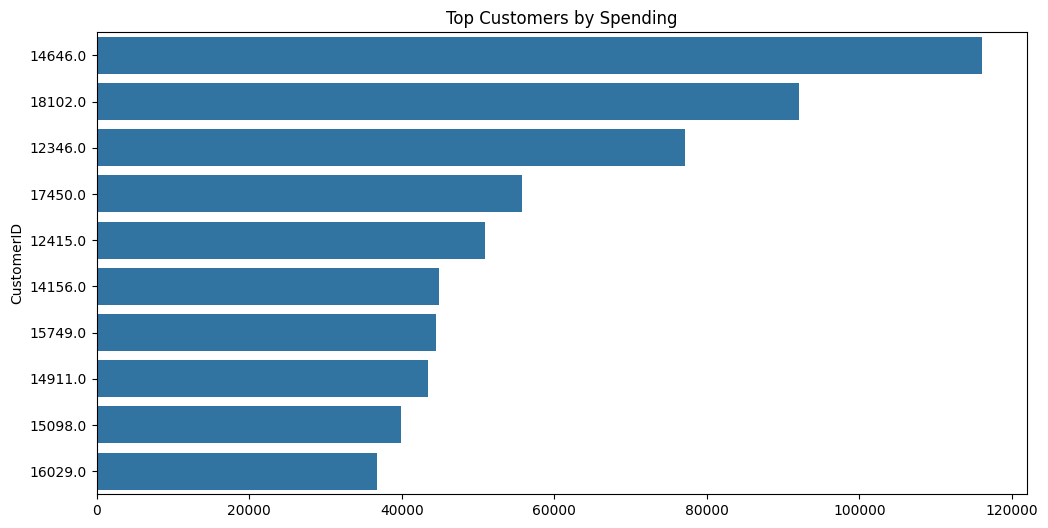

In [26]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=top_customers.values,
    y=top_customers.index.astype(str)
)

plt.title("Top Customers by Spending")

plt.show()

# RFM ANALYSIS

**Snapshot Date**

In [27]:
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

print(snapshot_date)

2023-06-13 12:01:00


**RFM Table**

In [28]:
rfm = df.groupby('CustomerID').agg({

    'InvoiceDate': lambda x:
        (snapshot_date - x.max()).days,

    'InvoiceNo': 'nunique',

    'TotalAmount': 'sum'

})

In [29]:
rfm.columns = [

    'Recency',
    'Frequency',
    'Monetary'

]

In [30]:
rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,146,1,77183.60
12347.0,3,4,2205.95
12348.0,69,3,1487.24
12350.0,130,1,334.40
12352.0,82,5,1561.81


In [31]:
rfm.shape

(2815, 3)

In [32]:
rfm.describe()

,Recency,Frequency,Monetary
count,2815.000000,2815.000000,2815.000000
mean,66.759858,2.822735,1276.679489
std,55.743994,4.213836,4425.596731
min,1.000000,1.000000,2.900000
25%,21.000000,1.000000,247.415000
50%,53.000000,2.000000,486.050000
75%,102.000000,3.000000,1099.220000
max,194.000000,92.000000,116135.920000


**Recency Distribution**

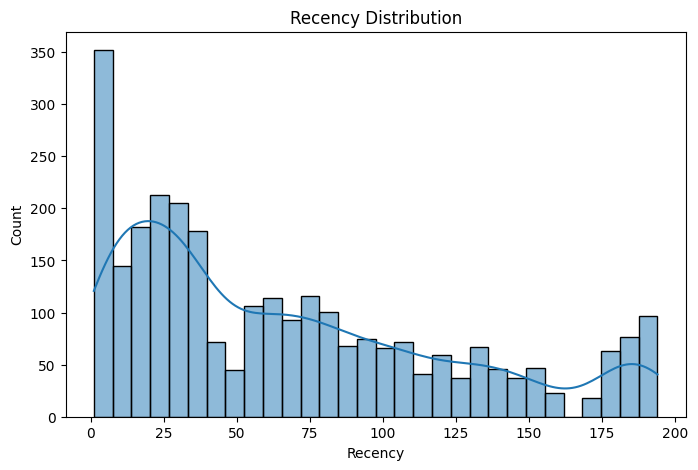

In [33]:
plt.figure(figsize=(8,5))

sns.histplot(
    rfm['Recency'],
    bins=30,
    kde=True
)

plt.title("Recency Distribution")
plt.show()

**Frequency Distribution**

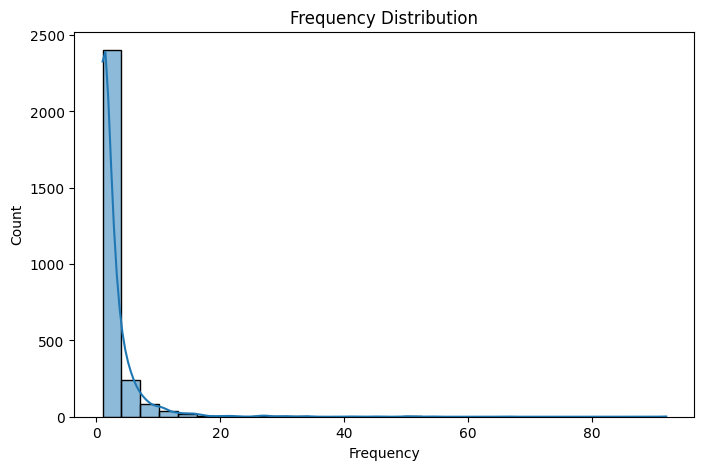

In [34]:
plt.figure(figsize=(8,5))

sns.histplot(
    rfm['Frequency'],
    bins=30,
    kde=True
)

plt.title("Frequency Distribution")
plt.show()

**Monetary Distribution**

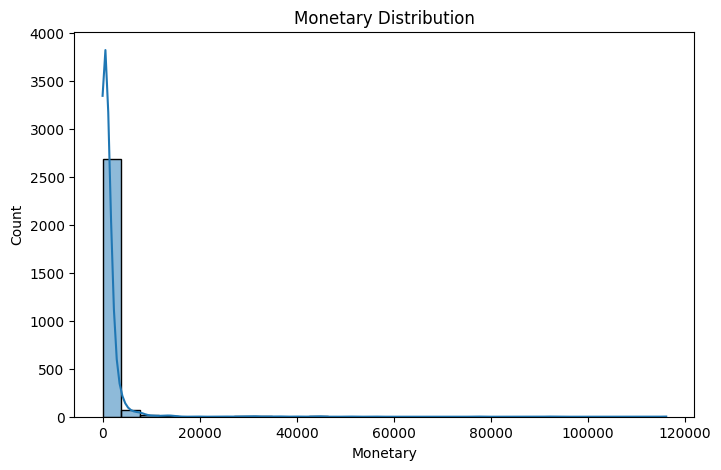

In [35]:
plt.figure(figsize=(8,5))

sns.histplot(
    rfm['Monetary'],
    bins=30,
    kde=True
)

plt.title("Monetary Distribution")
plt.show()

**Box Plots**

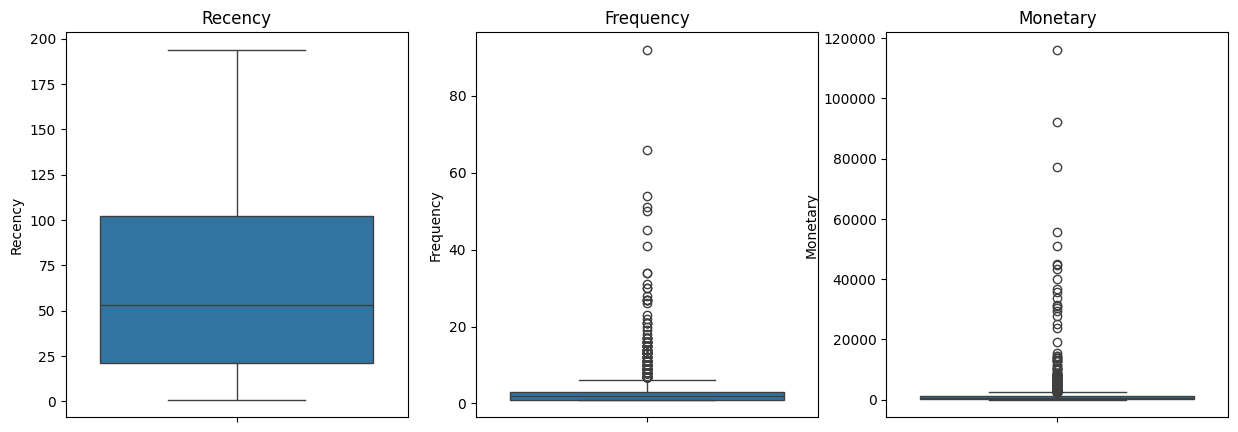

In [36]:
fig, ax = plt.subplots(
    1,3,
    figsize=(15,5)
)

sns.boxplot(
    y=rfm['Recency'],
    ax=ax[0]
)

ax[0].set_title("Recency")

sns.boxplot(
    y=rfm['Frequency'],
    ax=ax[1]
)

ax[1].set_title("Frequency")

sns.boxplot(
    y=rfm['Monetary'],
    ax=ax[2]
)

ax[2].set_title("Monetary")

plt.show()

In [37]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm)

In [38]:
rfm_scaled[:5]

array([[ 1.42175352, -0.4326365 , 17.15484064],
       [-1.14400101,  0.27943039,  0.21001362],
       [ 0.04019339,  0.04207476,  0.04758633],
       [ 1.13467609, -0.4326365 , -0.21295363],
       [ 0.2734438 ,  0.51678603,  0.06443903]])

**Elbow Curve**

In [39]:
from sklearn.cluster import KMeans

inertia = []

for k in range(2,11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42
    )

    kmeans.fit(rfm_scaled)

    inertia.append(
        kmeans.inertia_
    )

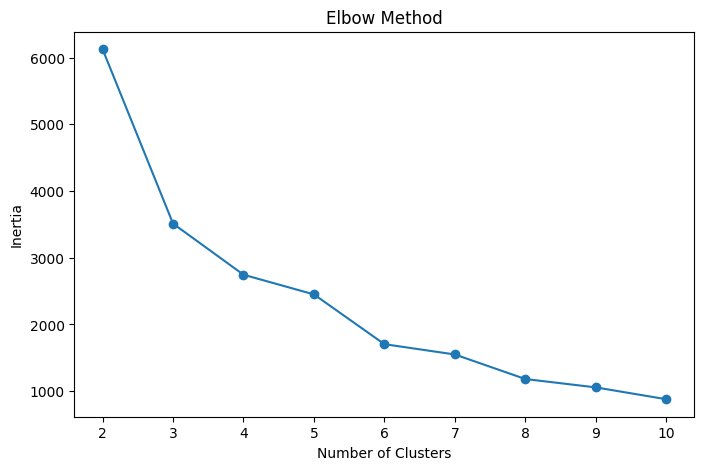

In [40]:
plt.figure(figsize=(8,5))

plt.plot(
    range(2,11),
    inertia,
    marker='o'
)

plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")

plt.show()

**Silhouette Score**

In [41]:
from sklearn.metrics import silhouette_score

for k in range(2,11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42
    )

    labels = kmeans.fit_predict(
        rfm_scaled
    )

    score = silhouette_score(
        rfm_scaled,
        labels
    )

    print(
        "K =", k,
        "S =", score
    )

K = 2 S = 0.45515581028318436
K = 3 S = 0.499950952108013
K = 4 S = 0.505550364325785
K = 5 S = 0.5052721916775428
K = 6 S = 0.5224583637285968
K = 7 S = 0.5102563840844451
K = 8 S = 0.44700935770015077
K = 9 S = 0.4356877794368738
K = 10 S = 0.4372759516561026


In [42]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42
)

rfm['Cluster'] = kmeans.fit_predict(
    rfm_scaled
)

In [43]:
rfm['Cluster'].value_counts()

,count
Cluster,
1,1824
0,960
3,23
2,8


In [44]:
cluster_profile = (

    rfm
    .groupby('Cluster')
    [['Recency',
      'Frequency',
      'Monetary']]
    .mean()

)

cluster_profile

,Recency,Frequency,Monetary
Cluster,,,
0,133.125000,1.282292,413.578677
1,32.618421,3.192982,1210.060346
2,32.500000,11.375000,65174.307500
3,16.217391,34.782609,20359.682609


#Customer Segemnetation

In [45]:
cluster_names = {

    0: "High Value",

    1: "At Risk",

    2: "Loyal",

    3: "VIP"

}

In [46]:
rfm['Segment'] = rfm['Cluster'].map(
    cluster_names
)

In [47]:
rfm.head()

,Recency,Frequency,Monetary,Cluster,Segment
CustomerID,,,,,
12346.0,146,1,77183.60,2,Loyal
12347.0,3,4,2205.95,1,At Risk
12348.0,69,3,1487.24,1,At Risk
12350.0,130,1,334.40,0,High Value
12352.0,82,5,1561.81,1,At Risk


**Segemnt Distribution**

Customer segmentation was performed using K-Means clustering on standardized RFM features. Four customer segments were identified. The VIP segment consists of customers with exceptionally high spending behavior. Loyal customers exhibit high purchase frequency and strong spending patterns. High-Value customers have made recent purchases and contribute significantly to revenue. At-Risk customers have lower spending and purchase frequency, indicating the need for targeted retention strategies.


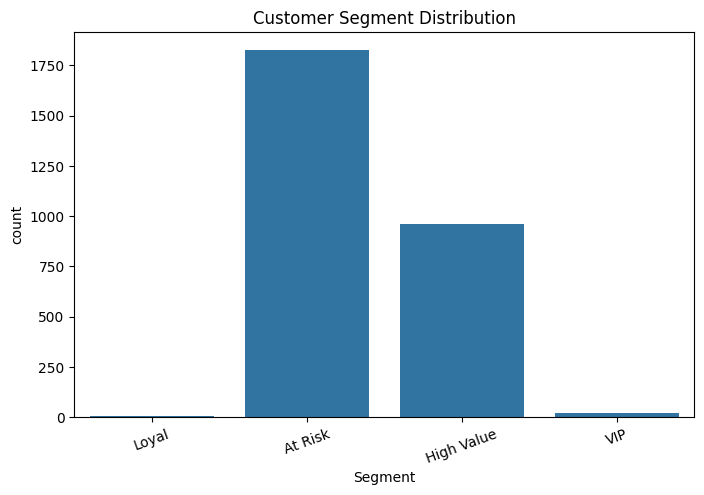

In [48]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=rfm,
    x='Segment'
)

plt.title(
    "Customer Segment Distribution"
)

plt.xticks(rotation=20)

plt.show()

In [49]:
segment_summary = (

    rfm
    .groupby('Segment')
    [['Recency',
      'Frequency',
      'Monetary']]
    .mean()

)

segment_summary

,Recency,Frequency,Monetary
Segment,,,
At Risk,32.618421,3.192982,1210.060346
High Value,133.125000,1.282292,413.578677
Loyal,32.500000,11.375000,65174.307500
VIP,16.217391,34.782609,20359.682609


**PCA Visualization**

In [50]:
from sklearn.decomposition import PCA
pca = PCA(
    n_components=2
)

pca_data = pca.fit_transform(
    rfm_scaled
)

In [51]:
pca_df = pd.DataFrame({

    'PCA1': pca_data[:,0],

    'PCA2': pca_data[:,1],

    'Segment': rfm['Segment']

})

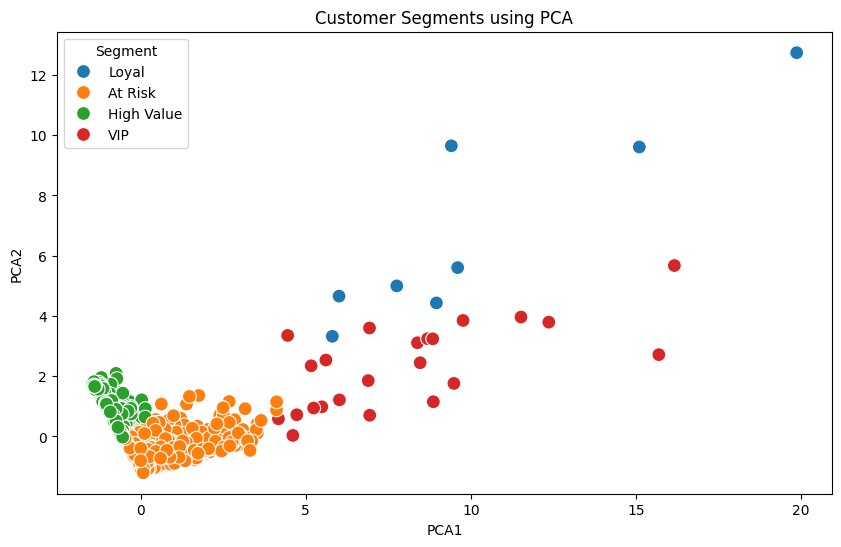

In [52]:
plt.figure(figsize=(10,6))

sns.scatterplot(

    data=pca_df,

    x='PCA1',

    y='PCA2',

    hue='Segment',

    s=100

)

plt.title(
    "Customer Segments using PCA"
)

plt.show()

In [53]:
import joblib

joblib.dump(
    kmeans,
    "kmeans.pkl"
)

joblib.dump(
    scaler,
    "scaler.pkl"
)

['scaler.pkl']

In [54]:
joblib.dump(
    cluster_names,
    "cluster_names.pkl"
)

['cluster_names.pkl']

#Product Recommendation System

In [55]:
customer_product = pd.pivot_table(
    df,
    index='Description',
    columns='CustomerID',
    values='Quantity',
    fill_value=0
)
customer_product.head()

CustomerID,12346.0,12347.0,12348.0,12350.0,12352.0,12353.0,12354.0,12355.0,12356.0,12359.0,...,18260.0,18263.0,18269.0,18270.0,18272.0,18273.0,18280.0,18281.0,18283.0,18287.0
Description,,,,,,,,,,,,,,,,,,,,,
4 PURPLE FLOCK DINNER CANDLES,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
OVAL WALL MIRROR DIAMANTE,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
SET 2 TEA TOWELS I LOVE LONDON,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
SPACEBOY BABY GIFT SET,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
10 COLOUR SPACEBOY PEN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,24.0,0.0,0.0,0.0,0.0,0.0,12.0,0.0


In [56]:
customer_product.shape

(3257, 2815)

In [57]:
from sklearn.metrics.pairwise import cosine_similarity
similarity = cosine_similarity(
    customer_product
)
similarity_df = pd.DataFrame(
    similarity,
    index=customer_product.index,
    columns=customer_product.index
)

In [58]:
similarity_df.head()

Description,4 PURPLE FLOCK DINNER CANDLES,OVAL WALL MIRROR DIAMANTE,SET 2 TEA TOWELS I LOVE LONDON,SPACEBOY BABY GIFT SET,10 COLOUR SPACEBOY PEN,12 COLOURED PARTY BALLOONS,12 DAISY PEGS IN WOOD BOX,12 EGG HOUSE PAINTED WOOD,12 IVORY ROSE PEG PLACE SETTINGS,12 MESSAGE CARDS WITH ENVELOPES,...,ZINC STAR T-LIGHT HOLDER,ZINC SWEETHEART SOAP DISH,ZINC SWEETHEART WIRE LETTER RACK,ZINC T-LIGHT HOLDER STAR LARGE,ZINC T-LIGHT HOLDER STARS LARGE,ZINC T-LIGHT HOLDER STARS SMALL,ZINC TOP 2 DOOR WOODEN SHELF,ZINC WILLIE WINKIE CANDLE STICK,ZINC WIRE KITCHEN ORGANISER,ZINC WIRE SWEETHEART LETTER TRAY
Description,,,,,,,,,,,,,,,,,,,,,
4 PURPLE FLOCK DINNER CANDLES,1.000000,0.000000,0.000588,0.000000,0.000000,0.000000,0.000000,0.000000,0.012335,0.002617,...,0.0,0.010193,0.000000,0.001196,0.000000,0.000633,0.000000,0.000000,0.0,0.005876
OVAL WALL MIRROR DIAMANTE,0.000000,1.000000,0.000060,0.000979,0.000000,0.000000,0.037213,0.049226,0.005024,0.031980,...,0.0,0.000000,0.779786,0.107798,0.000000,0.084377,0.023206,0.015937,0.0,0.861494
SET 2 TEA TOWELS I LOVE LONDON,0.000588,0.000060,1.000000,0.004943,0.010077,0.004096,0.000623,0.002157,0.000427,0.002105,...,0.0,0.000210,0.000657,0.002882,0.000000,0.001276,0.000469,0.000000,0.0,0.017360
SPACEBOY BABY GIFT SET,0.000000,0.000979,0.004943,1.000000,0.316161,0.031821,0.010183,0.004069,0.125826,0.012954,...,0.0,0.000000,0.000000,0.173992,0.019087,0.092645,0.000000,0.002206,0.0,0.000000
10 COLOUR SPACEBOY PEN,0.000000,0.000000,0.010077,0.316161,1.000000,0.015761,0.004376,0.004341,0.051833,0.000353,...,0.0,0.005491,0.000000,0.378971,0.000000,0.207215,0.000000,0.010665,0.0,0.000000


In [59]:
def recommend(product_name):
    try:
        similar_products = (
            similarity_df[product_name]
            .sort_values(ascending=False)
        )
        recommendations = (
            similar_products
            .iloc[1:6]
            .index
            .tolist()
        )
        return recommendations
    except:
        return ["Product Not Found"]

In [60]:
df['Description'].sample(10)

,Description
207081,PACK OF 60 DINOSAUR CAKE CASES
185833,FRIDGE MAGNETS US DINER ASSORTED
139399,TRAVEL CARD WALLET RETRO PETALS
97899,KINGS CHOICE TEA CADDY
118193,3 HOOK PHOTO SHELF ANTIQUE WHITE
91788,COOK WITH WINE METAL SIGN
31582,LARGE POPCORN HOLDER
95912,WHITE LOVEBIRD LANTERN
159818,GEMSTONE CHANDELIER T-LIGHT HOLDER
51626,BAKING MOULD CHOCOLATE CUPCAKES


In [61]:
product = input("Enter Product Name: ")
recommend(product)

Enter Product Name: WHITE METAL LANTERN


['GLASS BON BON JAR',
 'WRAP, BILLBOARD FONTS DESIGN',
 'CARD BILLBOARD FONT',
 'WRAP PINK FAIRY CAKES ',
 'FUNKY DIVA PEN']

In [62]:
sample_heatmap = similarity_df.iloc[:20,:20]

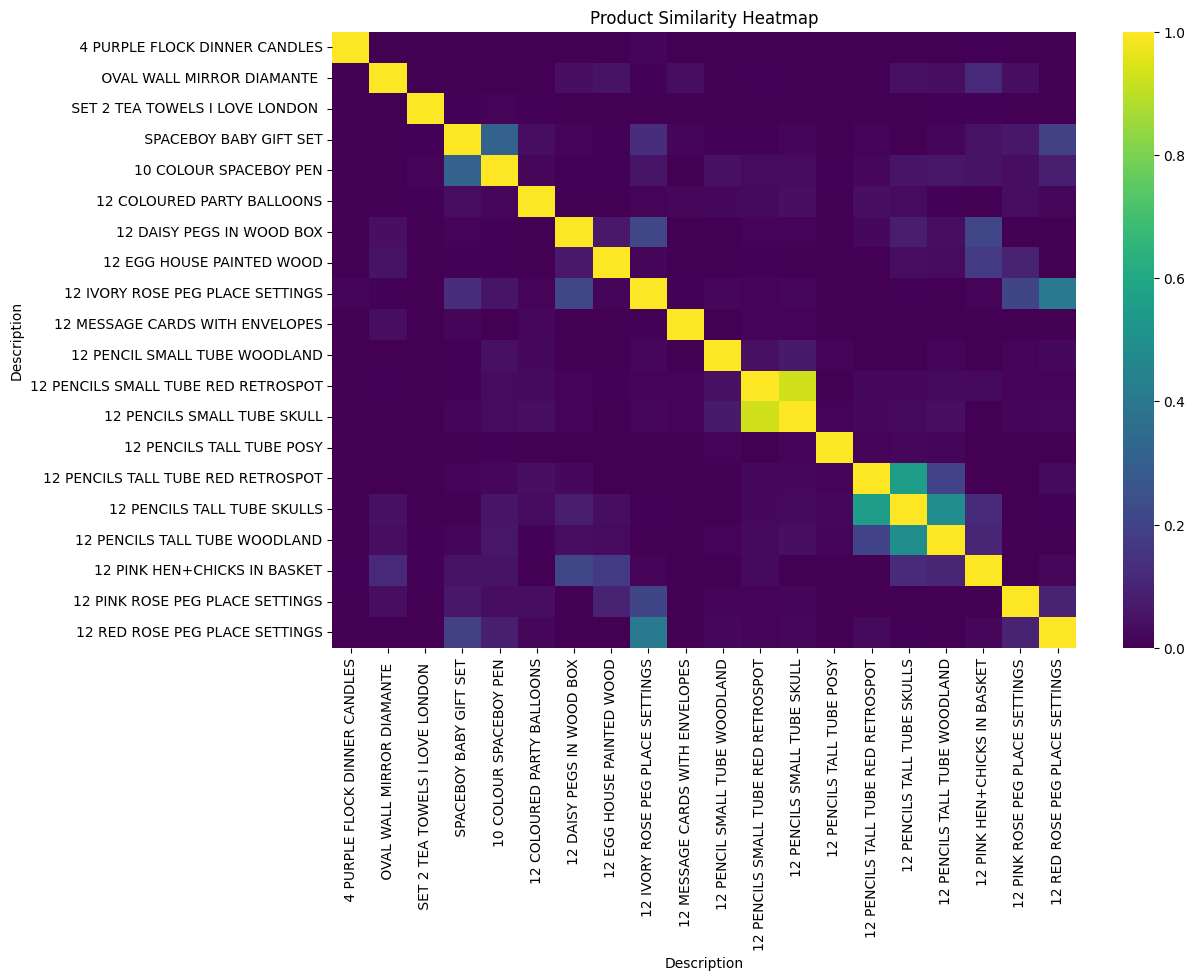

In [63]:
plt.figure(figsize=(12,8))
sns.heatmap(
    sample_heatmap,
    cmap='viridis'
)
plt.title(
    "Product Similarity Heatmap"
)
plt.show()

In [64]:
joblib.dump(
    similarity_df,
    "similarity.pkl"
)

['similarity.pkl']

In [65]:
import os
os.listdir()

['.config',
 'scaler.pkl',
 'cluster_names.pkl',
 'kmeans.pkl',
 'online_retail.csv',
 'similarity.pkl',
 'sample_data']

In [66]:
recommend("WHITE METAL LANTERN")

['GLASS BON BON JAR',
 'WRAP, BILLBOARD FONTS DESIGN',
 'CARD BILLBOARD FONT',
 'WRAP PINK FAIRY CAKES ',
 'FUNKY DIVA PEN']

The analysis identified distinct customer segments using RFM-based clustering. Most customers belonged to the At-Risk segment, while a small proportion represented High-Value, Loyal, and VIP customers. These segments can be used for personalized marketing campaigns and customer retention strategies.

An item-based collaborative filtering recommendation system was developed using cosine similarity. The model recommends products based on historical purchasing behavior, enabling personalized product suggestions and improving customer engagement.


In [67]:
def recommend_products(product_name, n=5):

    # Remove extra spaces and convert to lowercase
    product_name = product_name.strip().lower()

    # Create lowercase mapping
    product_mapping = {
        product.lower(): product
        for product in similarity_df.columns
    }

    # Check if product exists
    if product_name in product_mapping:

        original_name = product_mapping[product_name]

        recommendations = (
            similarity_df[original_name]
            .sort_values(ascending=False)
            .iloc[1:n+1]
            .index
            .tolist()
        )

        return recommendations

    return None

In [68]:
!pip install streamlit
import streamlit as st
import pandas as pd
import joblib
# =====================
# LOAD FILES
# =====================
kmeans = joblib.load("kmeans.pkl")
scaler = joblib.load("scaler.pkl")
cluster_names = joblib.load(
    "cluster_names.pkl"
)
similarity_df = joblib.load(
    "similarity.pkl"
)
# =====================
# PAGE TITLE
# =====================
st.title(
    "🛒 Shopper Spectrum"
)
st.subheader(
    "Customer Segmentation & Product Recommendation"
)
# =====================
# SIDEBAR
# =====================
option = st.sidebar.selectbox(
    "Choose Module",
    [
        "Customer Segmentation",
        "Product Recommendation"
    ]
)
# =====================
# CUSTOMER SEGMENTATION
# =====================
if option == "Customer Segmentation":
    st.header(
        "Customer Segmentation"
    )
    recency = st.number_input(
        "Recency (days)",
        min_value=0
    )
    frequency = st.number_input(
        "Frequency",
        min_value=0
    )
    monetary = st.number_input(
        "Monetary Value",
        min_value=0.0
    )
    if st.button("Predict Segment"):
        sample = scaler.transform([[
            recency,
            frequency,
            monetary
        ]])
        cluster = (
            kmeans.predict(sample)[0]
        )
        segment = (
            cluster_names[cluster]
        )
        st.success(
            f"Customer Segment: {segment}"
        )
# =====================
# PRODUCT RECOMMENDATION
# =====================
if option == "Product Recommendation":
    st.header(
        "Product Recommendation"
    )
    product = st.text_input(
        "Enter Product Name"
    )
    if st.button("Get Recommendations"):
        try:
            recommendations = (
                similarity_df[product]
                .sort_values(
                    ascending=False
                )
                .iloc[1:6]
                .index
                .tolist()
            )
            st.success(
                "Recommended Products"
            )
            for item in recommendations:
                st.write("✅", item)
        except:
            st.error(
                "Product Not Found"
            )

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 69.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 92.7 MB/s eta 0:00:00


2026-06-23 11:39:38.098 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-23 11:39:38.475 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-06-23 11:39:38.476 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-23 11:39:38.481 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-23 11:39:38.482 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-23 11:39:38.483 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-23 11:39:38.485 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-23 11:39:38.486 Thread 'MainThread': mi

In [69]:
%%writefile app.py

import streamlit as st
import pandas as pd
import joblib

# Load models
kmeans = joblib.load("kmeans.pkl")
scaler = joblib.load("scaler.pkl")
cluster_names = joblib.load("cluster_names.pkl")
similarity_df = joblib.load("similarity.pkl")

st.title("🛒 Shopper Spectrum")
st.subheader("Customer Segmentation & Product Recommendation")

option = st.sidebar.selectbox(
    "Choose Module",
    ["Customer Segmentation", "Product Recommendation"]
)

# Customer Segmentation
if option == "Customer Segmentation":

    st.header("Customer Segmentation")

    recency = st.number_input("Recency (days)", min_value=0)
    frequency = st.number_input("Frequency", min_value=0)
    monetary = st.number_input("Monetary", min_value=0.0)

    if st.button("Predict Segment"):

        sample = scaler.transform(
            [[recency, frequency, monetary]]
        )

        cluster = kmeans.predict(sample)[0]

        segment = cluster_names[cluster]

        st.success(
            f"Predicted Segment: {segment}"
        )

# Product Recommendation
if option == "Product Recommendation":

    st.header("Product Recommendation")

    product = st.text_input(
        "Enter Product Name"
    )

    if st.button("Get Recommendations"):

        try:

            recommendations = (
                similarity_df[product]
                .sort_values(ascending=False)
                .iloc[1:6]
                .index
                .tolist()
            )

            st.success("Recommended Products")

            for item in recommendations:
                st.write("✅", item)

        except:
            st.error("Product Not Found")

Writing app.py


In [70]:
if option == "Product Recommendation":

    st.header("🛍 Product Recommendation")

    product = st.text_input(
        "Enter Product Name"
    )

    if st.button("Get Recommendations"):

        recommendations = recommend_products(product)

        if recommendations:

            st.success("Recommended Products")

            for item in recommendations:

                st.write("✅", item)

        else:

            st.error("Product Not Found")

In [71]:
import os

os.listdir()

['.config',
 'scaler.pkl',
 'cluster_names.pkl',
 'app.py',
 'kmeans.pkl',
 'online_retail.csv',
 'similarity.pkl',
 'sample_data']

In [72]:
similarity_df[product]

,WHITE METAL LANTERN
Description,
4 PURPLE FLOCK DINNER CANDLES,0.000510
OVAL WALL MIRROR DIAMANTE,0.057098
SET 2 TEA TOWELS I LOVE LONDON,0.126510
SPACEBOY BABY GIFT SET,0.012873
10 COLOUR SPACEBOY PEN,0.000961
...,...
ZINC T-LIGHT HOLDER STARS SMALL,0.006829
ZINC TOP 2 DOOR WOODEN SHELF,0.012201
ZINC WILLIE WINKIE CANDLE STICK,0.036765


In [73]:
!wget -q https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64 -O cloudflared
!chmod +x cloudflared

In [74]:
!streamlit run app.py >/dev/null 2>&1 &

In [ ]:
!./cloudflared tunnel --url http://localhost:8501

2026-06-23T11:39:39Z INF Thank you for trying Cloudflare Tunnel. Doing so, without a Cloudflare account, is a quick way to experiment and try it out. However, be aware that these account-less Tunnels have no uptime guarantee, are subject to the Cloudflare Online Services Terms of Use (https://www.cloudflare.com/website-terms/), and Cloudflare reserves the right to investigate your use of Tunnels for violations of such terms. If you intend to use Tunnels in production you should use a pre-created named tunnel by following: https://developers.cloudflare.com/cloudflare-one/connections/connect-apps
2026-06-23T11:39:39Z INF Requesting new quick Tunnel on trycloudflare.com...
2026-06-23T11:39:43Z INF +--------------------------------------------------------------------------------------------+
2026-06-23T11:39:43Z INF |  Your quick Tunnel has been created! Visit it at (it may take some time to be reachable):  |
2026-06-23T11:39:43Z INF |  https://automobile-shops-silly-deviation.trycloudflar